In [29]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [30]:
QualCuts = {
    'pos_E_Ecal_low': 0.6,
    'pos_Px_low': -0.06,
    'ele_Ecal_z_low': 1448.6,
    'ele_Ecal_y_low': -85.0,
    'ele_Ecal_y_high': 85.0,
}

In [31]:
def make_df(file_path):
    df = pd.DataFrame()

    tritrig_file = uproot.open(file_path)

    # Open ROOT tree
    tree = tritrig_file['preselection']

    # Access branches
    B_vertex = tree['vertex.']
    B_ele = tree['ele.']
    B_pos = tree['pos.']

    # Get arrays of the electron and positron energies as measured with Ecal
    df['ele_E_Ecal'] = np.array(B_ele['ele.energy_'])
    df['pos_E_Ecal'] = np.array(B_pos['pos.energy_'])

    # Get Ecal cluster positions
    df['ele_Ecal_x']= np.array(B_ele['ele.cluster_.x_'])
    df['ele_Ecal_y']= np.array(B_ele['ele.cluster_.y_'])
    df['ele_Ecal_z']= np.array(B_ele['ele.cluster_.z_'])
    df['pos_Ecal_x']= np.array(B_pos['pos.cluster_.x_'])
    df['pos_Ecal_y']= np.array(B_pos['pos.cluster_.y_'])
    df['pos_Ecal_z']= np.array(B_pos['pos.cluster_.z_'])

    # Get Electron and Positron momenta
    df['pos_Px'] = B_pos['pos.px_'].array()
    df['pos_Py'] = B_pos['pos.py_'].array()
    df['pos_Pz'] = B_pos['pos.pz_'].array()
    df['ele_Px'] = B_ele['ele.px_'].array()
    df['ele_Py'] = B_ele['ele.py_'].array()
    df['ele_Pz'] = B_ele['ele.pz_'].array()


    #df['ele_chi2'] = B_ele['ele.track_.chi2_'].array()
    #df['pos_chi2'] = B_pos['pos.track_.chi2_'].array()
    #df['vtx_chi2'] = B_vertex['vertex.chi2_'].array()
    #df['ele_nhits'] = B_ele['ele.track_.n_hits_'].array()
    #df['pos_nhits'] = B_pos['pos.track_.n_hits_'].array()
    #df['ele_phi0'] = B_ele['ele.track_.phi0_'].array()
    #df['pos_phi0'] = B_pos['pos.track_.phi0_'].array()
    #df['InvM_err'] = B_vertex['vertex.invMerr_'].array()

    return df

In [32]:
# Create dataframes 
df_tritrig = make_df('/Users/mghrear/data/HPS_mc/2019_pass2/tritrig/tritrig.root')
df_phiKK = make_df('/Users/mghrear/data/HPS_mc/2019_pass2/phiKK/phiKK.root')
df_wab = make_df('/Users/mghrear/data/HPS_mc/2019_pass2/wab/wab.root')
df_FakeGen_1pt05_kaon = make_df('/Users/mghrear/data/HPS_mc/2019_pass2/FakeGen_1pt05/FakeGen.root')
df_data = make_df('/Users/mghrear/data/HPS_data/2019_pass2/preselection/merged_hps_010235_job76.root')
df_data_full = make_df('/Users/mghrear/data/HPS_data/2019_pass2/preselection_full/presel_full_hadd.root')

In [9]:
df_tritrig.to_pickle('/Users/mghrear/data/ML_data/2019_pass2/unscaled/2019_pass2_tritrig.pk')
df_phiKK.to_pickle('/Users/mghrear/data/ML_data/2019_pass2/unscaled/2019_pass2_phiKK.pk')
df_wab.to_pickle('/Users/mghrear/data/ML_data/2019_pass2/unscaled/2019_pass2_wab.pk')
df_data.to_pickle('/Users/mghrear/data/ML_data/2019_pass2/unscaled/2019_pass2_data.pk')
df_FakeGen_1pt05_kaon.to_pickle('/Users/mghrear/data/ML_data/2019_pass2/unscaled/2019_pass2_FakeGen_1pt05_kaon.pk')
df_data_full.to_pickle('/Users/mghrear/data/ML_data/2019_pass2/unscaled/2019_pass2_data_full.pk')

# Compare these attributes in data vs. monte carlo 

In [33]:
df_tritrig_study = df_tritrig.copy()
df_phiKK_study = df_phiKK.copy()
df_wab_study = df_wab.copy()
df_data_study = df_data.copy()

In [34]:
# Calculate invariant mass and add to dataframe
m_K = 0.493677

def calculate_invariant_mass_Ptot(df):
    # Calculate total electron momentum
    df['e_Ptot'] = np.sqrt(df['ele_Px']**2 + df['ele_Py']**2 + df['ele_Pz']**2)
    # Calculate total positron momentum
    df['p_Ptot'] = np.sqrt(df['pos_Px']**2 + df['pos_Py']**2 + df['pos_Pz']**2)
    df['e_SVT_E_K'] = m_K / np.sqrt ( 1 - ( df.e_Ptot**2 / (df.e_Ptot**2  + m_K**2) ) )
    df['p_SVT_E_K'] = m_K / np.sqrt ( 1 - ( df.p_Ptot**2 / (df.p_Ptot**2  + m_K**2) ) )
    df['M'] = np.sqrt((df.e_SVT_E_K+df.p_SVT_E_K)**2 - (df.ele_Px+df.pos_Px)**2 - (df.ele_Py+df.pos_Py)**2 - (df.ele_Pz+df.pos_Pz)**2)
    df['Ptot'] = df.e_Ptot + df.p_Ptot

    return df

df_tritrig_study = calculate_invariant_mass_Ptot(df_tritrig_study)
df_phiKK_study = calculate_invariant_mass_Ptot(df_phiKK_study)
df_wab_study = calculate_invariant_mass_Ptot(df_wab_study)
df_data_study = calculate_invariant_mass_Ptot(df_data_study)

_n_total = len(df_data_study)
_ratio_sum = 5129 + 1 + 791
n_tritrig = int(round(_n_total * 5129 / _ratio_sum))
n_phiKK   = int(round(_n_total * 1   / _ratio_sum))
n_wab     = _n_total - n_tritrig - n_phiKK

if n_wab <= len(df_wab_study):
    _wab_sample = df_wab_study.sample(n=n_wab, random_state=42)
else:
    _remainder = n_wab - len(df_wab_study)
    _wab_sample = pd.concat([
        df_wab_study,
        df_wab_study.sample(n=_remainder, random_state=42, replace=True),
    ], ignore_index=True)

df_combined_study = pd.concat([
    df_tritrig_study.sample(n=n_tritrig, random_state=42),
    df_phiKK_study.sample(n=n_phiKK,   random_state=42),
    _wab_sample,
], ignore_index=True, sort=False)

In [35]:
print(n_tritrig, n_phiKK, n_wab)

126993 25 19585


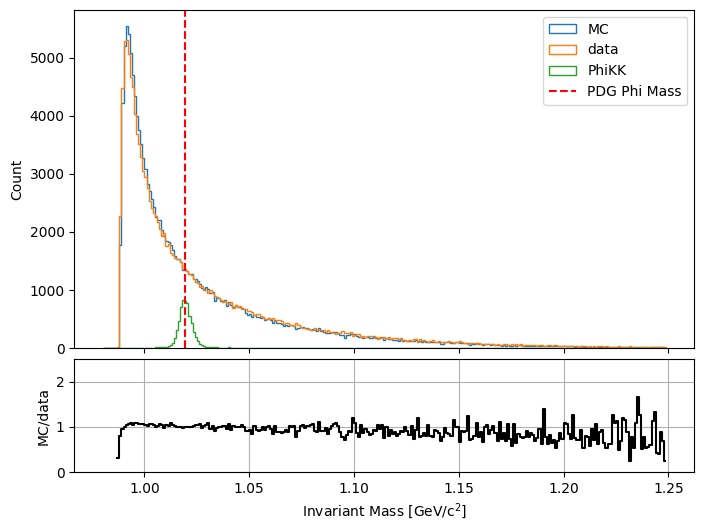

In [36]:
bins = np.arange(0.980, 1.250, 0.001)

mc   = df_combined_study['M'].to_numpy()
data = df_data_study['M'].to_numpy()
phiKK = df_phiKK_study['M'].to_numpy()

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(mc_counts, data_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=data_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=False, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=False, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=False, label='PhiKK')
ax_top.axvline(x=1.019461, color='r', linestyle='--', label='PDG Phi Mass')
ax_top.set_ylabel('Count')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('MC/data')
ax_bot.set_xlabel('Invariant Mass [GeV/c$^2$]')
ax_bot.set_ylim(0, 2.5)  # adjust as you like
ax_bot.grid(True)

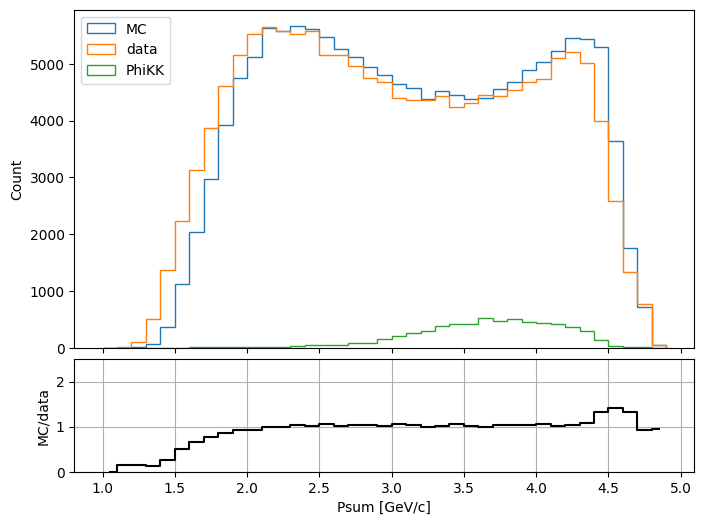

In [37]:
bins = np.arange(1,5.0,0.1)

mc   = df_combined_study['Ptot'].to_numpy()
data = df_data_study['Ptot'].to_numpy()
phiKK = df_phiKK_study['Ptot'].to_numpy()

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(mc_counts, data_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=data_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=False, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=False, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=False, label='PhiKK')
ax_top.set_ylabel('Count')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('MC/data')
ax_bot.set_xlabel('Psum [GeV/c]')
ax_bot.set_ylim(0, 2.5)  # adjust as you like
ax_bot.grid(True)

/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_16475/766120592.py:13: RuntimeWarning: divide by zero encountered in divide
  ratio = np.divide(data_counts, mc_counts,


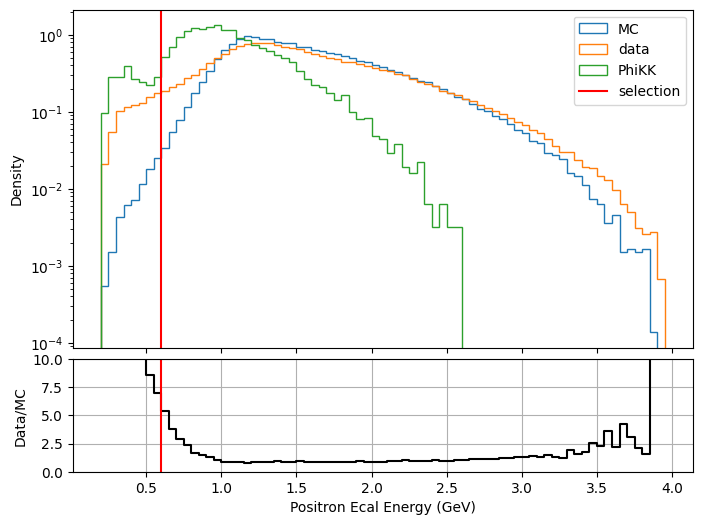

In [38]:

bins = np.arange(.2,4,0.05)

mc   = df_combined_study['pos_E_Ecal'].to_numpy()
data = df_data_study['pos_E_Ecal'].to_numpy()
phiKK = df_phiKK_study['pos_E_Ecal'].to_numpy()

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=data_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=True, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=True, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=True, label='PhiKK')
ax_top.axvline(QualCuts['pos_E_Ecal_low'], color ='red',label="selection")
ax_top.set_yscale('log')
ax_top.set_ylabel('Density')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('Data/MC')
ax_bot.set_xlabel('Positron Ecal Energy (GeV)')
ax_bot.set_ylim(0, 10)
ax_bot.axvline(QualCuts['pos_E_Ecal_low'], color ='red',label="selection")

ax_bot.grid(True)

In [39]:
print("MC Eff. = ", len(df_combined_study.loc[(df_combined_study['pos_E_Ecal'] > QualCuts['pos_E_Ecal_low'] )  ] ) / len(df_combined_study))
print("Data Eff. = ", len(df_data_study.loc[(df_data_study['pos_E_Ecal'] > QualCuts['pos_E_Ecal_low'] ) ] ) / len(df_data_study))
print("PhiKK Eff. = ", len(df_phiKK_study.loc[(df_phiKK_study['pos_E_Ecal'] > QualCuts['pos_E_Ecal_low'] ) ] ) / len(df_phiKK_study))

MC Eff. =  0.9962756560234102
Data Eff. =  0.9560923037045627
PhiKK Eff. =  0.8963414634146342


/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_16475/3696592502.py:13: RuntimeWarning: divide by zero encountered in divide
  ratio = np.divide(data_counts, mc_counts,


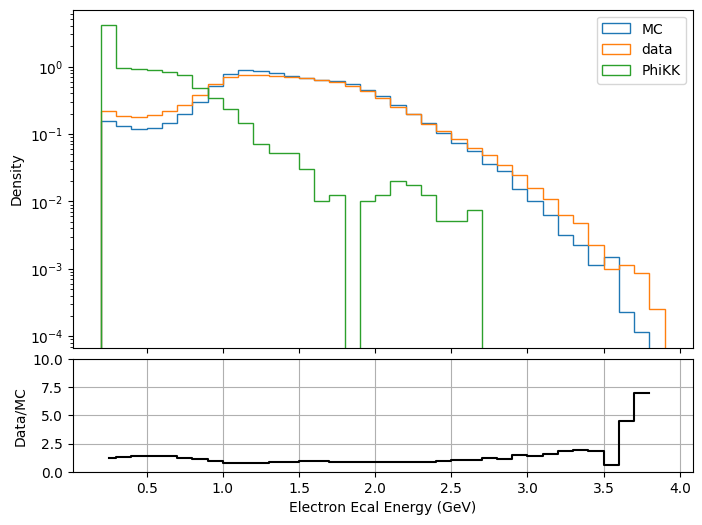

In [40]:
bins = np.arange(.2,4,0.1)

mc   = df_combined_study['ele_E_Ecal'].to_numpy()
data = df_data_study['ele_E_Ecal'].to_numpy()
phiKK = df_phiKK_study['ele_E_Ecal'].to_numpy()

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=data_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=True, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=True, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=True, label='PhiKK')
ax_top.set_yscale('log')
ax_top.set_ylabel('Density')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('Data/MC')
ax_bot.set_xlabel('Electron Ecal Energy (GeV)')
ax_bot.set_ylim(0, 10)
ax_bot.grid(True)

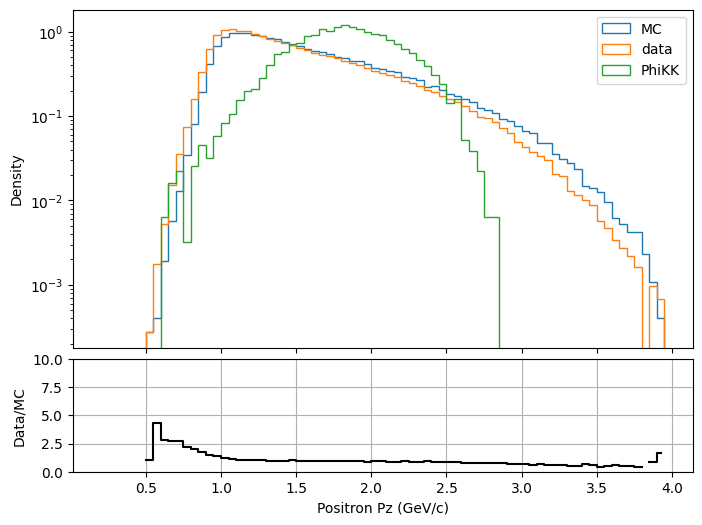

In [41]:
bins = np.arange(.2,4,0.05)

mc   = df_combined_study['pos_Pz'].to_numpy()
data = df_data_study['pos_Pz'].to_numpy()
phiKK = df_phiKK_study['pos_Pz'].to_numpy()

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=data_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=True, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=True, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=True, label='PhiKK')
ax_top.set_yscale('log')
ax_top.set_ylabel('Density')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('Data/MC')
ax_bot.set_xlabel('Positron Pz (GeV/c)')
ax_bot.set_ylim(0, 10)
ax_bot.grid(True)

/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_16475/2190325882.py:13: RuntimeWarning: divide by zero encountered in divide
  ratio = np.divide(data_counts, mc_counts,


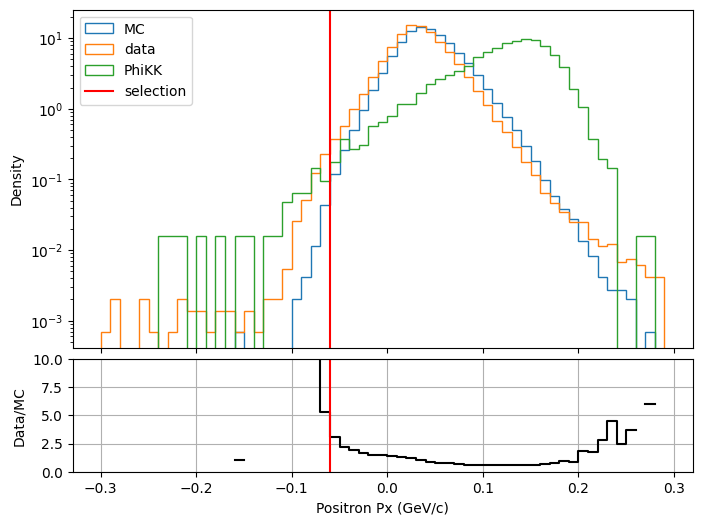

In [42]:
bins = np.arange(-.3,.3,0.01)

mc   = df_combined_study['pos_Px'].to_numpy()
data = df_data_study['pos_Px'].to_numpy()
phiKK = df_phiKK_study['pos_Px'].to_numpy()

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=data_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=True, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=True, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=True, label='PhiKK')
ax_top.axvline(QualCuts['pos_Px_low'], color ='red',label="selection")
ax_top.set_yscale('log')
ax_top.set_ylabel('Density')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('Data/MC')
ax_bot.set_xlabel('Positron Px (GeV/c)')
ax_bot.axvline(QualCuts['pos_Px_low'], color ='red',label="selection")
ax_bot.set_ylim(0, 10)
ax_bot.grid(True)

In [117]:
print("MC Eff. = ", len(df_combined_study.loc[(df_combined_study['pos_Px'] > QualCuts['pos_Px_low'] ) ] ) / len(df_combined_study))
print("Data Eff. = ", len(df_data_study.loc[(df_data_study['pos_Px'] > QualCuts['pos_Px_low'] )  ] ) / len(df_data_study))
print("PhiKK Eff. = ", len(df_phiKK_study.loc[(df_phiKK_study['pos_Px'] > QualCuts['pos_Px_low']) ] ) / len(df_phiKK_study))

MC Eff. =  0.9993792760039016
Data Eff. =  0.9953957286003697
PhiKK Eff. =  0.9943838254172015


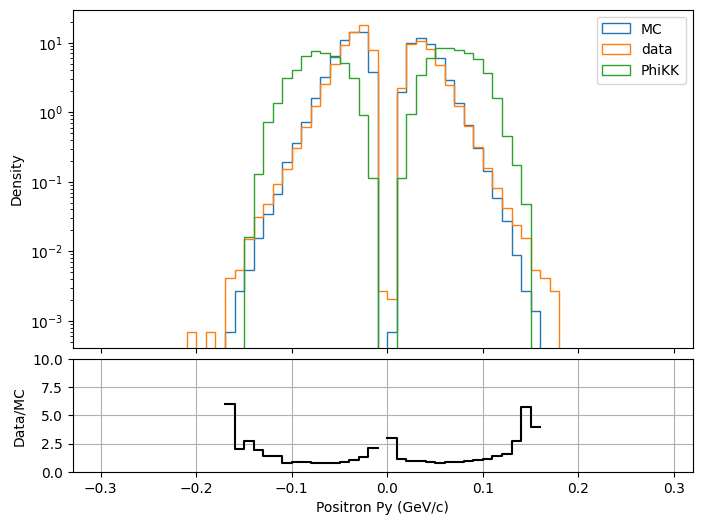

In [43]:
bins = np.arange(-.3,.3,0.01)

mc   = df_combined_study['pos_Py'].to_numpy()
data = df_data_study['pos_Py'].to_numpy()
phiKK = df_phiKK_study['pos_Py'].to_numpy()

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=mc_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=True, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=True, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=True, label='PhiKK')
ax_top.set_yscale('log')
ax_top.set_ylabel('Density')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('Data/MC')
ax_bot.set_xlabel('Positron Py (GeV/c)')
ax_bot.set_ylim(0, 10)
ax_bot.grid(True)

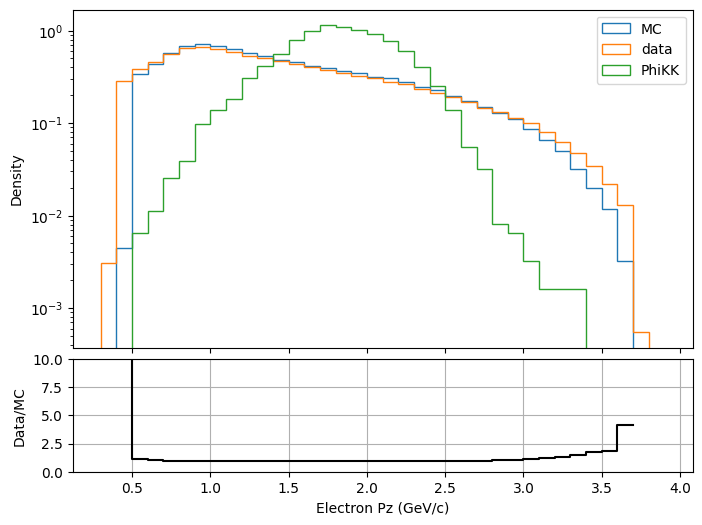

In [44]:
bins = np.arange(.3,4,0.1)

mc   = df_combined_study['ele_Pz'].to_numpy()
data = df_data_study['ele_Pz'].to_numpy()
phiKK = df_phiKK_study['ele_Pz'].to_numpy()

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=mc_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=True, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=True, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=True, label='PhiKK')
ax_top.set_yscale('log')
ax_top.set_ylabel('Density')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('Data/MC')
ax_bot.set_xlabel('Electron Pz (GeV/c)')
ax_bot.set_ylim(0, 10)
ax_bot.grid(True)

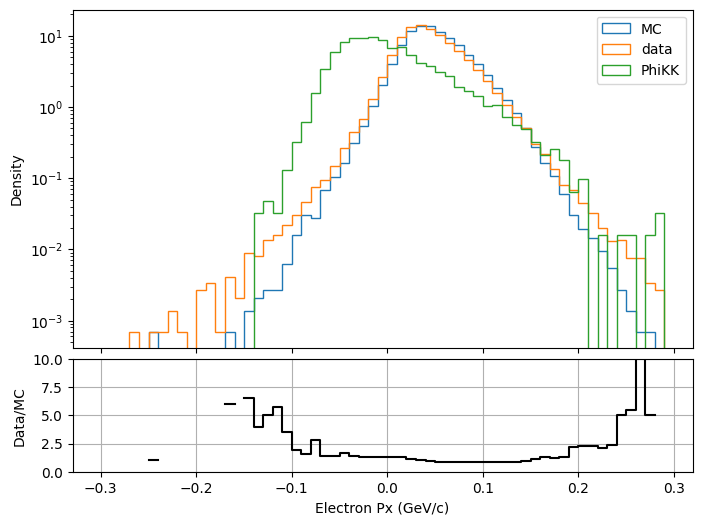

In [45]:
bins = np.arange(-.3,.3,0.01)

mc   = df_combined_study['ele_Px'].to_numpy()
data = df_data_study['ele_Px'].to_numpy()
phiKK = df_phiKK_study['ele_Px'].to_numpy()

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=mc_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=True, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=True, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=True, label='PhiKK')
ax_top.set_yscale('log')
ax_top.set_ylabel('Density')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('Data/MC')
ax_bot.set_xlabel('Electron Px (GeV/c)')
ax_bot.set_ylim(0, 10)
ax_bot.grid(True)

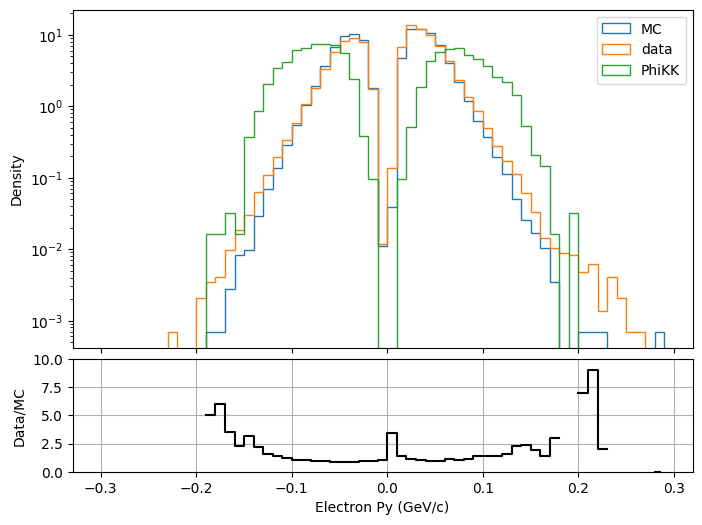

In [46]:
bins = np.arange(-.3,.3,0.01)

mc   = df_combined_study['ele_Py'].to_numpy()
data = df_data_study['ele_Py'].to_numpy()
phiKK = df_phiKK_study['ele_Py'].to_numpy()

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=mc_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=True, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=True, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=True, label='PhiKK')
ax_top.set_yscale('log')
ax_top.set_ylabel('Density')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('Data/MC')
ax_bot.set_xlabel('Electron Py (GeV/c)')
ax_bot.set_ylim(0, 10)
ax_bot.grid(True)

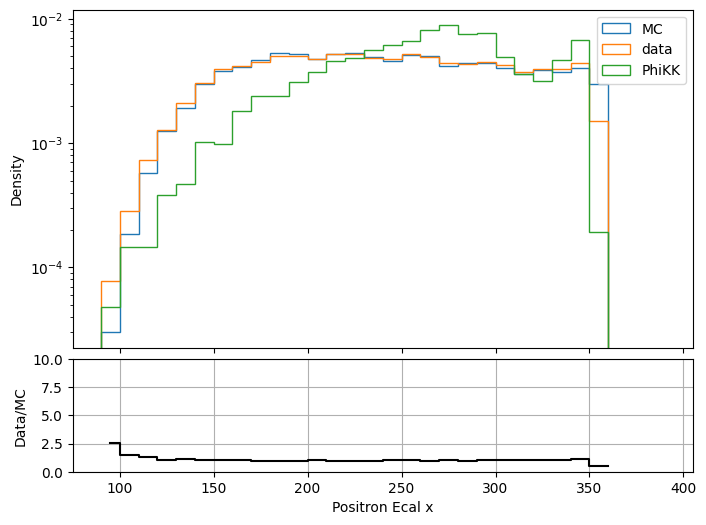

In [47]:
bins = np.arange(90,400,10)

mc   = df_combined_study['pos_Ecal_x'].to_numpy()#*100
data = df_data_study['pos_Ecal_x'].to_numpy()#*100
phiKK = df_phiKK_study['pos_Ecal_x'].to_numpy()#*100

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=mc_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=True, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=True, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=True, label='PhiKK')
ax_top.set_yscale('log')
ax_top.set_ylabel('Density')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('Data/MC')
ax_bot.set_xlabel('Positron Ecal x')
ax_bot.set_ylim(0, 10)
ax_bot.grid(True)

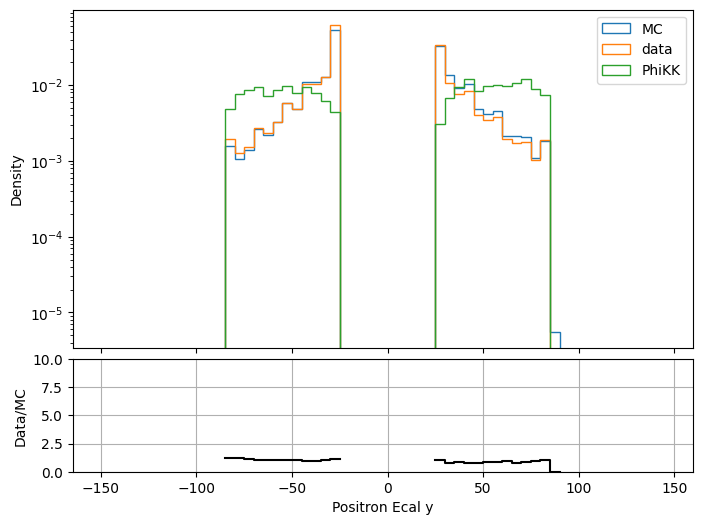

In [48]:
bins = np.arange(-150,150,5)

mc   = df_combined_study['pos_Ecal_y'].to_numpy()#*100
data = df_data_study['pos_Ecal_y'].to_numpy()#*100
phiKK = df_phiKK_study['pos_Ecal_y'].to_numpy()#*100

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=mc_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=True, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=True, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=True, label='PhiKK')
ax_top.set_yscale('log')
ax_top.set_ylabel('Density')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('Data/MC')
ax_bot.set_xlabel('Positron Ecal y')
ax_bot.set_ylim(0, 10)
ax_bot.grid(True)

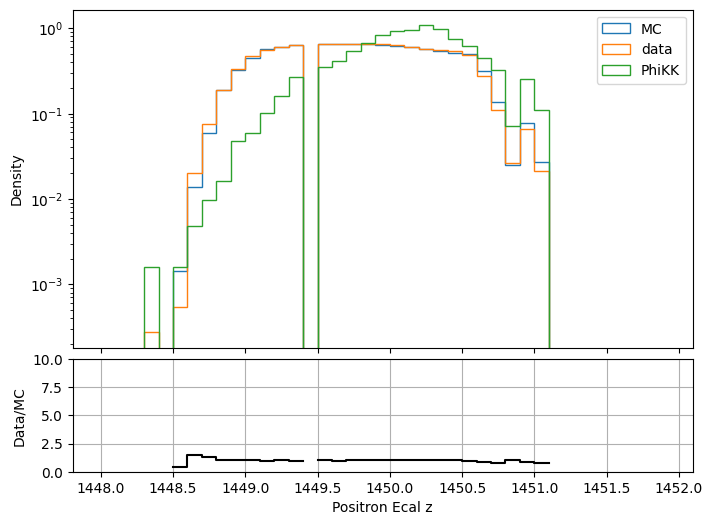

In [49]:
bins = np.arange(1448,1452,.1)

mc   = df_combined_study['pos_Ecal_z'].to_numpy()#*100
data = df_data_study['pos_Ecal_z'].to_numpy()#*100
phiKK = df_phiKK_study['pos_Ecal_z'].to_numpy()#*100

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=mc_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=True, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=True, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=True, label='PhiKK')
ax_top.set_yscale('log')
ax_top.set_ylabel('Density')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('Data/MC')
ax_bot.set_xlabel('Positron Ecal z')
ax_bot.set_ylim(0, 10)
ax_bot.grid(True)

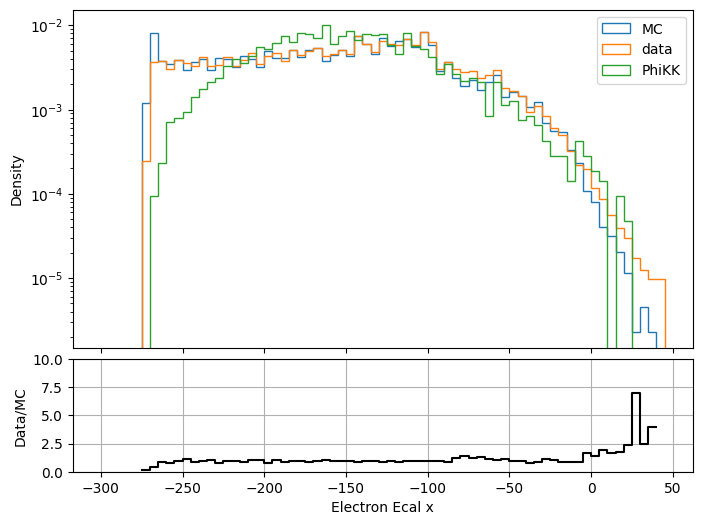

In [50]:
bins = np.arange(-300,50,5)

mc   = df_combined_study['ele_Ecal_x'].to_numpy()#*100
data = df_data_study['ele_Ecal_x'].to_numpy()#*100
phiKK = df_phiKK_study['ele_Ecal_x'].to_numpy()#*100

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=mc_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=True, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=True, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=True, label='PhiKK')
ax_top.set_yscale('log')
ax_top.set_ylabel('Density')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('Data/MC')
ax_bot.set_xlabel('Electron Ecal x')
ax_bot.set_ylim(0, 10)
ax_bot.grid(True)

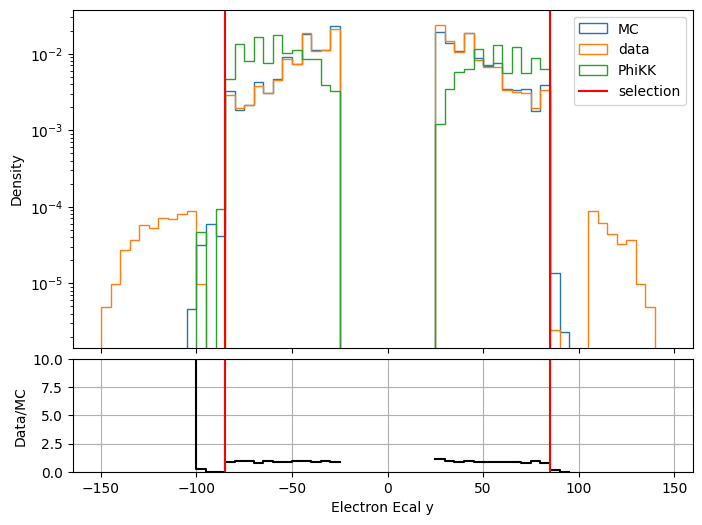

In [51]:
bins = np.arange(-150,150,5)

mc   = df_combined_study['ele_Ecal_y'].to_numpy()#*100
data = df_data_study['ele_Ecal_y'].to_numpy()#*100
phiKK = df_phiKK_study['ele_Ecal_y'].to_numpy()#*100

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=mc_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=True, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=True, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=True, label='PhiKK')
ax_top.axvline(QualCuts['ele_Ecal_y_low'], color ='red',label="selection")
ax_top.axvline(QualCuts['ele_Ecal_y_high'], color ='red')

ax_top.set_yscale('log')
ax_top.set_ylabel('Density')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('Data/MC')
ax_bot.set_xlabel('Electron Ecal y')
ax_bot.axvline(QualCuts['ele_Ecal_y_low'], color ='red',label="selection")
ax_bot.axvline(QualCuts['ele_Ecal_y_high'], color ='red')

ax_bot.set_ylim(0, 10)
ax_bot.grid(True)

In [52]:
# ele_Ecal_y selection efficiency
print("MC Eff. = ", len(df_combined_study.loc[((df_combined_study['ele_Ecal_y'] > QualCuts['ele_Ecal_y_low']) & (df_combined_study['ele_Ecal_y'] < QualCuts['ele_Ecal_y_high'])) | (df_combined_study['ele_Ecal_y'] == -9999.0)]) / len(df_combined_study))
print("Data Eff. = ", len(df_data_study.loc[((df_data_study['ele_Ecal_y'] > QualCuts['ele_Ecal_y_low']) & (df_data_study['ele_Ecal_y'] < QualCuts['ele_Ecal_y_high'])) | (df_data_study['ele_Ecal_y'] == -9999.0)]) / len(df_data_study))
print("PhiKK Eff. = ", len(df_phiKK_study.loc[((df_phiKK_study['ele_Ecal_y'] > QualCuts['ele_Ecal_y_low']) & (df_phiKK_study['ele_Ecal_y'] < QualCuts['ele_Ecal_y_high'])) | (df_phiKK_study['ele_Ecal_y'] == -9999.0)]) / len(df_phiKK_study))

MC Eff. =  0.9995429834314441
Data Eff. =  0.997803592013806
PhiKK Eff. =  0.9995186136071887


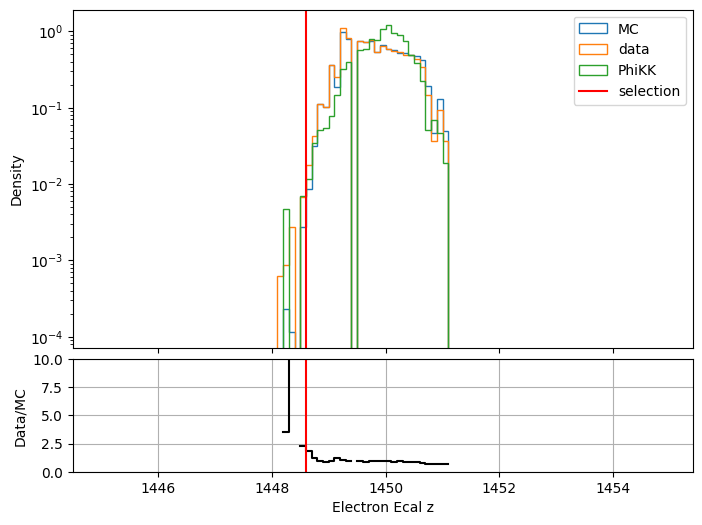

In [53]:
bins = np.arange(1445,1455,.1)

mc   = df_combined_study['ele_Ecal_z'].to_numpy()#*100
data = df_data_study['ele_Ecal_z'].to_numpy()#*100
phiKK = df_phiKK_study['ele_Ecal_z'].to_numpy()#*100

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=mc_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=True, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=True, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=True, label='PhiKK')
ax_top.axvline(QualCuts['ele_Ecal_z_low'], color ='red',label="selection")
ax_top.set_yscale('log')
ax_top.set_ylabel('Density')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('Data/MC')
ax_bot.set_xlabel('Electron Ecal z')
ax_bot.axvline(QualCuts['ele_Ecal_z_low'], color ='red',label="selection")
ax_bot.set_ylim(0, 10)
ax_bot.grid(True)

In [54]:
print("MC Eff. = ", len(df_combined_study.loc[(df_combined_study['ele_Ecal_z'] > QualCuts['ele_Ecal_z_low']) | (df_combined_study['ele_Ecal_z'] == -9999.0)   ] ) / len(df_combined_study))
print("Data Eff. = ", len(df_data_study.loc[(df_data_study['ele_Ecal_z'] > QualCuts['ele_Ecal_z_low'])  | (df_data_study['ele_Ecal_z'] == -9999.0)   ] ) / len(df_data_study))
print("PhiKK Eff. = ", len(df_phiKK_study.loc[(df_phiKK_study['ele_Ecal_z'] > QualCuts['ele_Ecal_z_low']) | (df_phiKK_study['ele_Ecal_z'] == -9999.0)   ] ) / len(df_phiKK_study))

MC Eff. =  0.9998158291440148
Data Eff. =  0.9993929182895303
PhiKK Eff. =  0.9991976893453145


In [130]:
def getmask(df, QualCuts):
    mask = (
        (df['pos_E_Ecal'] > QualCuts['pos_E_Ecal_low']) &
        (df['pos_Px'] > QualCuts['pos_Px_low']) &
        ((df['ele_Ecal_z'] > QualCuts['ele_Ecal_z_low']) | (df['ele_Ecal_z'] == -9999.0)) &
        (((df['ele_Ecal_y'] > QualCuts['ele_Ecal_y_low']) & (df['ele_Ecal_y'] < QualCuts['ele_Ecal_y_high'])) | (df['ele_Ecal_y'] == -9999.0))
    )
    return mask

In [131]:
df_combined_study_1 = df_combined_study.loc[getmask(df_combined_study, QualCuts)]
df_data_study_1 = df_data_study.loc[getmask(df_data_study, QualCuts)]
df_phiKK_study_1 = df_phiKK_study.loc[getmask(df_phiKK_study, QualCuts)]


print(len(df_combined_study_1)/len(df_combined_study))
print(len(df_data_study_1)/len(df_data_study))
print(len(df_phiKK_study_1)/len(df_phiKK_study))

0.9950478503168421
0.9499942020286078
0.8939345314505777
